In [1]:
import numpy as np
import pandas as pd
from uniswap_v2_sim import uniswap_v2_sim
import gymnasium as gym
from gymnasium import spaces
import math
import matplotlib.pyplot as plt

In [2]:
class uniswapV2Backtest(gym.Env):
    def __init__(
            self,
            vol_token_pool: uniswap_v2_sim,
            nav_in_honey,
            vol_part,
            timestamps,
            top_leverage,
            bottom_leverage,
            min_cr = 1.2,
            boundary_debt_per_loop = 0.9/1.2,
            collateral_LP = 1,
            horizon = 600,
        ):
        
        super(uniswapV2Backtest, self).__init__()

        self.nav = nav_in_honey.copy()
        self.vol_part = vol_part.copy()
        self.pool = vol_token_pool
        self.max_episodes = len(self.nav)
        self.agent_timestamps = timestamps.copy()
        self.top_leverage = top_leverage
        self.bottom_leverage = bottom_leverage
        self.min_cr = min_cr
        self.boundary_debt_per_loop = boundary_debt_per_loop
        self.lp = collateral_LP
        self.max_relative_commulative_debt = 1/(min_cr - 1)
        self.horizon = horizon

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=0, high=1, shape=(10,), dtype=np.float32)

    def reset(self, seed = None, options = None, top_leverage = None, bottom_leverage = None):
        super().reset(seed=seed)

        if top_leverage is not None:
            self.top_leverage = top_leverage

        if bottom_leverage is not None:
            self.bottom_leverage = bottom_leverage

        self.history_economics = {
            'leverage': [],
            'PNL': [],
            'return': [],
            'collaterization ratio': [],
            'vol token amount': [],
            'nect debt': [],
            'vol token price': [],
            'total loss': [],
            'nav': [],
            'calm part': [],
            'timestamp': []
        }

        self.step_count = 0

        self.timestamp = self.agent_timestamps[self.step_count]
        self.pool.set_history_timestamp(self.timestamp)
        self.current_vol_token_price = self.pool.get_price('volatile')
        self.current_nav = self.nav[self.step_count]
        self.current_vol_part = self.vol_part[self.step_count]
        self.current_calm_part = 1 - self.vol_part[self.step_count]

        self.collateral_value = self.lp*self.current_nav

        self.target_leverage = (self.top_leverage + self.bottom_leverage)/2
        self.top_target_leverage = (self.top_leverage + self.target_leverage)/2
        self.bottom_target_leverage = (self.target_leverage + self.bottom_leverage)/2

        self.primordial_leverage = self._get_primordial_leverage_init()
        #_, self.primordial_leverage = self._get_naive_primordial_leverage()
        self.commulative_debt = self.primordial_leverage*self.collateral_value
        self.commulative_lp = self.commulative_debt/self.current_nav

        x = self.current_calm_part*(self.target_leverage - self.primordial_leverage - 1)
            
        self.vol_token_value = x*self.collateral_value
        self.vol_token = self.vol_token_value/self.current_vol_token_price
        self.noncommulative_debt = self.vol_token_value

        self.leverage = x/self.current_calm_part + self.primordial_leverage + 1

        self.total_lp_value = self.collateral_value + self.commulative_lp*self.current_nav
        self.total_debt_value = self.noncommulative_debt + self.commulative_debt
        self.cr = self.total_lp_value/self.total_debt_value
        self.vol_token_normed = x

        self.leverage_history = np.zeros(self.horizon)
        self.leverage_history[0] = self.leverage
        self.relative_vol_token_value_history = np.zeros(self.horizon)
        self.relative_vol_token_value_history[0] = self.vol_token_normed
        self.calm_part_history = np.zeros(self.horizon)
        self.calm_part_history[0] = self.current_calm_part

        self.leverage_mean = np.sum(self.leverage_history)/min(self.step_count + 1, self.horizon)
        self.leverage_gain_mean = self._get_average_gain(self.leverage_history)
        self.vol_token_mean = np.sum(self.relative_vol_token_value_history)/min(self.step_count + 1, self.horizon)
        self.vol_token_gain_mean = self._get_average_gain(self.relative_vol_token_value_history)
        self.calm_part_mean = np.sum(self.calm_part_history)/min(self.step_count + 1, self.horizon)
        self.calm_part_gain_mean = self._get_average_gain(self.calm_part_history)

        self.norm = self.top_leverage - self.bottom_leverage

        self.leverage_normed = (self.leverage - self.bottom_leverage)/self.norm
        self.leverage_mean_normed = (self.leverage_mean - self.bottom_leverage)/self.norm
        self.leverage_gain_mean_normed = self._normalize_slope(self.leverage_gain_mean)
        self.vol_token_gain_mean_normed = self._normalize_slope(self.vol_token_gain_mean)
        self.calm_part_gain_mean_normed = self._normalize_slope(self.calm_part_gain_mean)

        self.cr_normed = 1/(self.cr)

        self.recent_reward = 1
        self.relative_loss = 0
        self.total_loss = 0
        self.losses_history = np.zeros(self.horizon)
        self.recenet_total_loss = 0

        self.portfolio_value = self.vol_token_value + self.total_lp_value - self.total_debt_value
        self.initial_portfolio_value = self.vol_token_value + self.total_lp_value - self.total_debt_value

        self.current_action_penalty = 0
        self._update_history()

        obs = self._get_obs()
        info = {}
        return obs, info
    
    def _get_obs(self):
        return np.array([
            self.leverage_normed,
            self.cr_normed,
            self.leverage_mean_normed,
            self.leverage_gain_mean_normed,
            self.vol_token_normed,
            self.vol_token_mean,
            self.vol_token_gain_mean_normed,
            self.current_calm_part,
            self.calm_part_mean,
            self.calm_part_gain_mean_normed
        ], dtype=np.float32)

    def step(self, action):

        if action != 0 and action != 4:
            if action == 1:
                x = self.current_calm_part*(self.target_leverage - self.primordial_leverage - 1)
            else:
                if action == 2:
                    x = self.current_calm_part*(self.top_target_leverage - self.primordial_leverage - 1)
                else:
                    x = self.current_calm_part*(self.bottom_target_leverage - self.primordial_leverage - 1)

            new_vol_token_value = x*self.collateral_value
            new_vol_token = new_vol_token_value/self.current_vol_token_price

            if new_vol_token < self.vol_token:
                vt_to_sell = self.vol_token - new_vol_token
                vt_sold, nect_to_repay = self.pool.make_swap(vt_to_sell, 'volatile', is_pure=True)

                self.noncommulative_debt -= nect_to_repay
                self.vol_token = new_vol_token

                recent_loss_nect = vt_to_sell*self.current_vol_token_price - nect_to_repay
                self.recent_loss_value = recent_loss_nect
            else:
                vt_to_buy = new_vol_token - self.vol_token
                nect_to_borrow = vt_to_buy*self.current_vol_token_price

                self.noncommulative_debt += nect_to_borrow
                
                nect_sold, vt_bought = self.pool.make_swap(nect_to_borrow, 'stable', is_pure=True)
                self.vol_token += vt_bought

                recent_loss_vt = vt_to_buy - vt_bought
                self.recent_loss_value = recent_loss_vt*self.pool.get_price('volatile')
        else:
            self.recent_loss_value = 0

        self.relative_loss += self.recent_loss_value/self.collateral_value
        self.total_loss += self.recent_loss_value
        prev_loss = self.losses_history[self.step_count % self.horizon]
        self.losses_history[self.step_count % self.horizon] = self.relative_loss
        self.recenet_total_loss = self.relative_loss - prev_loss

        self.step_count += 1

        self.timestamp = self.agent_timestamps[self.step_count]
        self.pool.make_history_simulation(self.timestamp)
        self.current_vol_token_price = self.pool.get_price('volatile')
        self.current_nav = self.nav[self.step_count]
        self.current_vol_part = self.vol_part[self.step_count]
        self.current_calm_part = 1 - self.vol_part[self.step_count]

        self.collateral_value = self.lp*self.current_nav
        self.vol_token_value = self.vol_token*self.current_vol_token_price
        self.total_lp_value = self.collateral_value + self.commulative_lp*self.current_nav
        self.total_debt_value = self.noncommulative_debt + self.commulative_debt

        x = self.vol_token_value/self.collateral_value
        leverage = x/self.current_calm_part + self.primordial_leverage + 1
        self.leverage_gain = leverage - self.leverage
        self.leverage = leverage

        self.cr = self.total_lp_value/self.total_debt_value

        self.vol_token_normed = x
        self.boundary_leverage = self._get_boundary_leverage(self.primordial_leverage)

        self.leverage_history[self.step_count % self.horizon] = self.leverage
        self.relative_vol_token_value_history[self.step_count % self.horizon] = self.vol_token_normed
        self.calm_part_history[self.step_count % self.horizon] = self.current_calm_part

        self.leverage_mean = np.sum(self.leverage_history)/min(self.step_count + 1, self.horizon)
        self.vol_token_mean = np.sum(self.relative_vol_token_value_history)/min(self.step_count + 1, self.horizon)
        self.calm_part_mean = np.sum(self.calm_part_history)/min(self.step_count + 1, self.horizon)

        self.leverage_gain_mean = self._get_average_gain(self.leverage_history)
        self.vol_token_gain_mean = self._get_average_gain(self.relative_vol_token_value_history)
        self.calm_part_gain_mean = self._get_average_gain(self.calm_part_history)

        self.boundary_leverage_normed = (self.boundary_leverage - self.bottom_leverage)/self.norm
        self.leverage_normed = (self.leverage - self.bottom_leverage)/self.norm
        self.leverage_mean_normed = (self.leverage_mean - self.bottom_leverage)/self.norm

        self.leverage_gain_mean_normed = self._normalize_slope(self.leverage_gain_mean)
        self.vol_token_gain_mean_normed = self._normalize_slope(self.vol_token_gain_mean)
        self.calm_part_gain_mean_normed = self._normalize_slope(self.calm_part_gain_mean)

        self.cr_normed = min(1/max(self.cr + 1e-6, 1e-10), 1)

        reward = 0
        self.recent_reward = reward

        self.portfolio_value = self.vol_token_value + self.total_lp_value - self.total_debt_value

        self._update_history()

        if self.boundary_leverage_normed <= 1:
            print(self.timestamp, self.boundary_leverage_normed)
            self._rebalance_loop()
        terminated = self.cr<=self.min_cr
        truncated = self.step_count >= self.max_episodes - 1
        obs = self._get_obs()
        info = {}

        done = terminated or truncated
        if done:
            saved = {k: v.copy() for k, v in self.history_economics.items()}
            info['episode_economics'] = saved
            info['top leverage'] = self.top_leverage
            info['bottom leverage'] = self.bottom_leverage

        return obs, reward, terminated, truncated, info

    def _update_history(self):
        self.history_economics['leverage'].append(self.leverage)
        self.history_economics['PNL'].append(self.portfolio_value - self.initial_portfolio_value)
        self.history_economics['return'].append(self.portfolio_value/self.initial_portfolio_value - 1)
        self.history_economics['collaterization ratio'].append(self.cr)
        self.history_economics['vol token amount'].append(self.vol_token)
        self.history_economics['nect debt'].append(self.total_debt_value)
        self.history_economics['vol token price'].append(self.current_vol_token_price)
        self.history_economics['total loss'].append(self.total_loss)
        self.history_economics['nav'].append(self.current_nav)
        self.history_economics['calm part'].append(100*self.current_calm_part)
        self.history_economics['timestamp'].append(self.timestamp)

    def _normalize_gain(self, gain, scale = 0.001):
        gain = gain/self.norm
        sin = gain/math.sqrt(scale**2 + gain**2)
        return (sin + 1)/2

    def _get_average_gain(self, series):
        n = min(self.step_count + 1, self.horizon)
        if n < 2:
            return 0
        i_0 = self.step_count % self.horizon
        mu = (n - 1)/2
        sum_1 = 0
        sum_2 = 0
        for i in range(n):
            idx = (i_0 - n + 1 + i) % n  
            sum_1 += (i - mu) * series[idx]
            sum_2 += (i - mu)**2
        return sum_1 / sum_2

    def _normalize_slope(self, slope):
        alpha = math.atan(8000/self.horizon*min(self.step_count + 1, self.horizon)*slope)
        return (2/math.pi*alpha + 1)/2

    def _rebalance_loop(self):
        self.primordial_leverage = self._get_primordial_leverage_init()

        self.commulative_debt_value = self.primordial_leverage*self.collateral_value
        self.commulative_lp = self.commulative_debt_value/self.current_nav
        self.commulative_debt = self.commulative_debt_value

        self.target_leverage = (self.top_leverage + self.bottom_leverage)/2
        x = self.current_calm_part*(self.target_leverage - self.primordial_leverage - 1)

        self.vol_token_value = x*self.collateral_value
        self.vol_token = self.vol_token_value/self.current_vol_token_price
        self.noncommulative_debt = self.vol_token_value

    def _get_naive_primordial_leverage(self):
        acceptable_boundary_leverage = self.target_leverage + 0.1*(self.top_leverage - self.bottom_leverage)
        x = 1 - acceptable_boundary_leverage*(1 - self.boundary_debt_per_loop)

        if x <= 0:
            return 0, 1

        n = int(math.log(x)/math.log(self.boundary_debt_per_loop))
        n = max(1, n)

        return n, (1 - self.boundary_debt_per_loop**n)/(1 - self.boundary_debt_per_loop) - 1
    
    def _get_prev_primordial_leverage(self, leverage):
        return (leverage - 1)/self.boundary_debt_per_loop
    
    def _get_next_primordial_leverage(self, leverage):
        return 1 + self.boundary_debt_per_loop*leverage
    
    def _get_boundary_leverage_init(self, prim_leverage):
        x_max = (1 + prim_leverage)/self.min_cr - prim_leverage
        return x_max/self.current_calm_part + prim_leverage + 1
    
    def _get_boundary_leverage(self, prim_leverage):
        y2 = self.commulative_debt/self.collateral_value
        x_max = (1 + prim_leverage)/self.min_cr - y2
        max_debt_value = x_max*self.collateral_value
        max_borrow = max_debt_value - self.noncommulative_debt
        x_max = self.vol_token_normed + max_borrow/self.collateral_value
        return x_max/self.current_calm_part + prim_leverage + 1
    
    def _get_primordial_leverage_init(self):
        n, prim_leverage = self._get_naive_primordial_leverage()
        acceptable_boundary_leverage = self.top_target_leverage + 0.1*(self.top_leverage - self.bottom_leverage)

        while True:
            if n <= 1:
                break
            n_new = n - 1
            new_prim_leverage = self._get_prev_primordial_leverage(prim_leverage + 1) - 1
            new_boundary_leverage = self._get_boundary_leverage_init(new_prim_leverage)
            if new_boundary_leverage < acceptable_boundary_leverage:
                break
            else:
                n = n_new
                prim_leverage = new_prim_leverage

        return (1 - self.boundary_debt_per_loop**n)/(1 - self.boundary_debt_per_loop) - 1

In [3]:
pool_history_df = pd.read_csv('history_event.csv')
event_timestamp = pool_history_df['timestamp'].values
types = pool_history_df['type'].values
token0 = pool_history_df['token0'].values
token1 = pool_history_df['token1'].values
ts = pool_history_df['lp_token'].values
gas = pool_history_df['gas'].values

init_token0 = 71349330974
init_token1 = 75599411
init_total_supply = 1590604863

event_history = {
    'timestamp': event_timestamp,
    'type': types,
    'token0': token0,
    'token1': token1,
    'lp_token': ts,
    'gas': gas
}

df = pd.read_csv('wbtc_test_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamp = df['timestamp'].values

df_extr = pd.read_csv('wbtc_train_data_expanded.csv')
nav_extr = df_extr['nav'].values
nect_price_extr = df_extr['nect_price'].values
vol_token_price_extr = df_extr['wbtc_price'].values
volatile_part_extr = df_extr['wbtc_frac'].values
timestamp_extr = df_extr['timestamp'].values


print(len(nav))
print(len(nav_extr))
nav = np.concatenate((nav_extr, nav))
print(len(nav))
nect_price = np.concatenate((nect_price_extr, nect_price))
vol_token_price = np.concatenate((vol_token_price_extr, vol_token_price))
volatile_part = np.concatenate((volatile_part_extr, volatile_part))
timestamp = np.concatenate((timestamp_extr, timestamp))

12046
48180
60226


In [4]:
print(timestamp[0])
print(timestamp[1])
print(timestamp[::4][0])
print(timestamp[::4][1])
print(timestamp[::4][2])
print(timestamp[::4][1] - timestamp[::4][0])
print(timestamp[::4][2] - timestamp[::4][1])
print(timestamp[::4][3] - timestamp[::4][2])
print(timestamp[::4][4] - timestamp[::4][3])
print(timestamp[::4][5] - timestamp[::4][4])

1744776696.0
1744776894.0
1744776696.0
1744777497.0
1744778304.0
801.0
807.0
797.0
798.0
791.0


In [5]:
scale0 = 10**6
scale1 = 10**8

print(init_token0/scale0)
print(init_token1/scale1)
price = (init_token0/scale0)/(init_token1/scale1)
print(price)
print(1000/price)

71349.330974
0.75599411
94378.1572240027
0.010595672022145345


In [6]:
pool = uniswap_v2_sim(
    init_token0,
    init_token1,
    init_total_supply,
    6,
    8,
    event_history,
    token0_name = 'stable',
    token1_name = 'volatile'
)

In [7]:
"""print(pool.get_price('volatile'))
print(pool.reserve1/10**pool.decimals1)

pool.set_history_timestamp(1754167806)

print(pool.get_price('volatile'))
print(pool.reserve1/10**pool.decimals1)

pool.make_history_simulation(1756497889)

print(pool.get_price('volatile'))
print(pool.reserve1/10**pool.decimals1)"""

"print(pool.get_price('volatile'))\nprint(pool.reserve1/10**pool.decimals1)\n\npool.set_history_timestamp(1754167806)\n\nprint(pool.get_price('volatile'))\nprint(pool.reserve1/10**pool.decimals1)\n\npool.make_history_simulation(1756497889)\n\nprint(pool.get_price('volatile'))\nprint(pool.reserve1/10**pool.decimals1)"

In [8]:
def naiveAgent(obs, min_cr=1.2):
    leverage = obs[0]
    cr = 1/obs[1]

    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        return 1
    else:
        return 0

In [9]:
def plot_economic_metrics(histories, labels, top_leverage, bottom_leverage, mic_cr = 1.2, name = None):
    n = len(histories)

    fig, axs = plt.subplots(10, 1, figsize=(12, 20), sharex=True)

    if 'timestamp' in histories[0]:
        timestamp = histories[0]['timestamp']
        timestamp = np.array(timestamp)
        date = timestamp.astype("datetime64[s]")
        fig.supxlabel('date')
    else:
        fig.supxlabel('step')
        date = None

    if date is not None:
        for i in range(n):
            axs[0].plot(date, histories[i]['leverage'], label = labels[i])
    else:
        for i in range(n):
            axs[0].plot(histories[i]['leverage'], label = labels[i])
    axs[0].axhline(top_leverage, color='r', linestyle='--', label='leverage boundary')
    axs[0].axhline(bottom_leverage, color='r', linestyle='--')
    axs[0].set_ylabel('leverage')
    axs[0].legend()
    
    if date is not None:
        for i in range(n):
            axs[1].plot(date, histories[i]['PNL'], label = labels[i])
    else:
        for i in range(n):
            axs[1].plot(histories[i]['PNL'], label = labels[i])
    axs[1].set_ylabel('PNL (in usd)')
    axs[1].legend()

    if date is not None:
        for i in range(n):
            axs[2].plot(date, histories[i]['return'], label = labels[i])
    else:
        for i in range(n):
            axs[2].plot(histories[i]['return'], label = labels[i])
    axs[2].set_ylabel('return, %')
    axs[2].legend()

    if date is not None:
        for i in range(n):
            axs[3].plot(date, histories[i]['collaterization ratio'], label = labels[i])
    else:
        for i in range(n):
            axs[3].plot(histories[i]['collaterization ratio'], label = labels[i])
    axs[3].axhline(mic_cr, color='r', linestyle='--', label='minimal cr')
    axs[3].set_ylabel('collaterization ratio')
    axs[3].legend()

    if date is not None:
        for i in range(n):
            axs[4].plot(date, histories[i]['vol token amount'], label = labels[i])
    else:
        for i in range(n):
            axs[4].plot(histories[i]['vol token amount'], label = labels[i])
    axs[4].set_ylabel('volatile token amount')
    axs[4].legend()

    if date is not None:
        for i in range(n):
            axs[5].plot(date, histories[i]['nect debt'], label = labels[i])
    else:
        for i in range(n):
            axs[5].plot(histories[i]['nect debt'], label = labels[i])
    axs[5].set_ylabel('total debt value (in usd)')
    axs[5].legend()

    if date is not None:
        for i in range(n):
            axs[6].plot(date, histories[i]['vol token price'], label = labels[i])
    else:
        for i in range(n):
            axs[6].plot(histories[i]['vol token price'], label = labels[i])
    axs[6].set_ylabel('volatile token price (in usd)')
    axs[6].legend()

    if date is not None:
        for i in range(n):
            axs[7].plot(date, histories[i]['total loss'], label = labels[i])
    else:
        for i in range(n):
            axs[7].plot(histories[i]['total loss'], label = labels[i])
    axs[7].set_ylabel('transaction losses (in usd)')
    axs[7].legend()

    if date is not None:
        for i in range(n):
            axs[8].plot(date, histories[i]['nav'], label = labels[i])
    else:
        for i in range(n):
            axs[8].plot(histories[i]['nav'], label = labels[i])
    axs[8].set_ylabel('LP token nav (in usd)')
    axs[8].legend()

    if date is not None:
        for i in range(n):
            axs[9].plot(date, histories[i]['calm part'], label = labels[i])
    else:
        for i in range(n):
            axs[9].plot(histories[i]['calm part'], label = labels[i])
    axs[9].set_ylabel('LP token calm part, %')
    axs[9].legend()

    if name is not None:
        fig.suptitle("name")

    plt.tight_layout()
    plt.show()

In [10]:
from torch_model import reccurentActor

model = reccurentActor()
model.set_initial_state('actor_weights.pth')

c:\Proga\leverege_simul\for_server\tester_uniswap_v2\torch_model.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file_path, map_location = device)


In [11]:
eval_env = uniswapV2Backtest(
    pool,
    nav[::4],
    volatile_part[::4],
    timestamp[::4],
    2.4,
    1.6,
    collateral_LP = 0.0001
)

obs, _ = eval_env.reset()
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, hidden = model.act(obs, hidden)
    if action == 1:
        if abs(obs[0] - 0.5) < 0.1:
            action == 0
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated
    if done:
        bot_history = info['episode_economics']

1747881437.0 0.9996935153180516
1747882214.0 0.9897020048170332
1747882995.0 0.9897020048170332
1747883776.0 0.9897020048633312
1747884554.0 0.9892831769530971
1747885336.0 0.9821463358713386
1747886119.0 0.9571213805967712
1747886899.0 0.958390854183744
1747887679.0 0.9581922837111314
1747888456.0 0.9582966144110868
1747889232.0 0.9582353561968362
1747890013.0 0.9583188167891629
1747890794.0 0.9584927628806785
1747891576.0 0.9584935013654646
1747892352.0 0.9583808685715713
1747893135.0 0.9583387228004144
1747893912.0 0.9666546534448769
1747894692.0 0.9667538425726082
1747895468.0 0.9701474595265177
1747896248.0 0.967707487167291
1747897019.0 0.9745410544147878
1747897800.0 0.9777747106437015
1747898582.0 0.977679462932279
1747899366.0 0.9778511572526629
1747900144.0 0.9778518772948904
1747900923.0 0.9767384056260194
1747901704.0 0.977116355336787
1747902492.0 0.9739679532365438
1747903276.0 0.9777652433022501
1747904056.0 0.9784980280125618
1747904835.0 0.9826879844990207
1747905615.0

In [12]:
eval_env = uniswapV2Backtest(
    pool,
    nav[::4],
    volatile_part[::4],
    timestamp[::4],
    2.4,
    1.6,
    collateral_LP = 0.0001
)

obs, _ = eval_env.reset()
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated
    if done:
        mech_agent_history = info['episode_economics']

1747881437.0 0.999259430015856
1747882214.0 0.9897020048170332
1747882995.0 0.9897020048170332
1747883776.0 0.9897020048633306
1747884554.0 0.9892831769530971
1747885336.0 0.9821463358713386
1747886119.0 0.9571213860958357
1747886899.0 0.958390854183744
1747887679.0 0.9581922837111314
1747888456.0 0.9582966279951829
1747889232.0 0.9582353561968362
1747890013.0 0.9583188275770124
1747890794.0 0.9584927628806785
1747891576.0 0.9584935013654646
1747892352.0 0.9583808737658891
1747893135.0 0.9583387228004144
1747893912.0 0.9666546535594985
1747894692.0 0.9667538425726082
1747895468.0 0.9701474599275447
1747896248.0 0.967707487167291
1747897019.0 0.9745410615840163
1747897800.0 0.9777747106437015
1747898582.0 0.977679462932279
1747899366.0 0.9778511573438561
1747900144.0 0.9778518772948904
1747900923.0 0.9767384056260194
1747901704.0 0.9771163577579797
1747902492.0 0.9739679576218132
1747903276.0 0.9777652433022501
1747904056.0 0.9784980280125618
1747904835.0 0.9826879848884859
1747905615.0

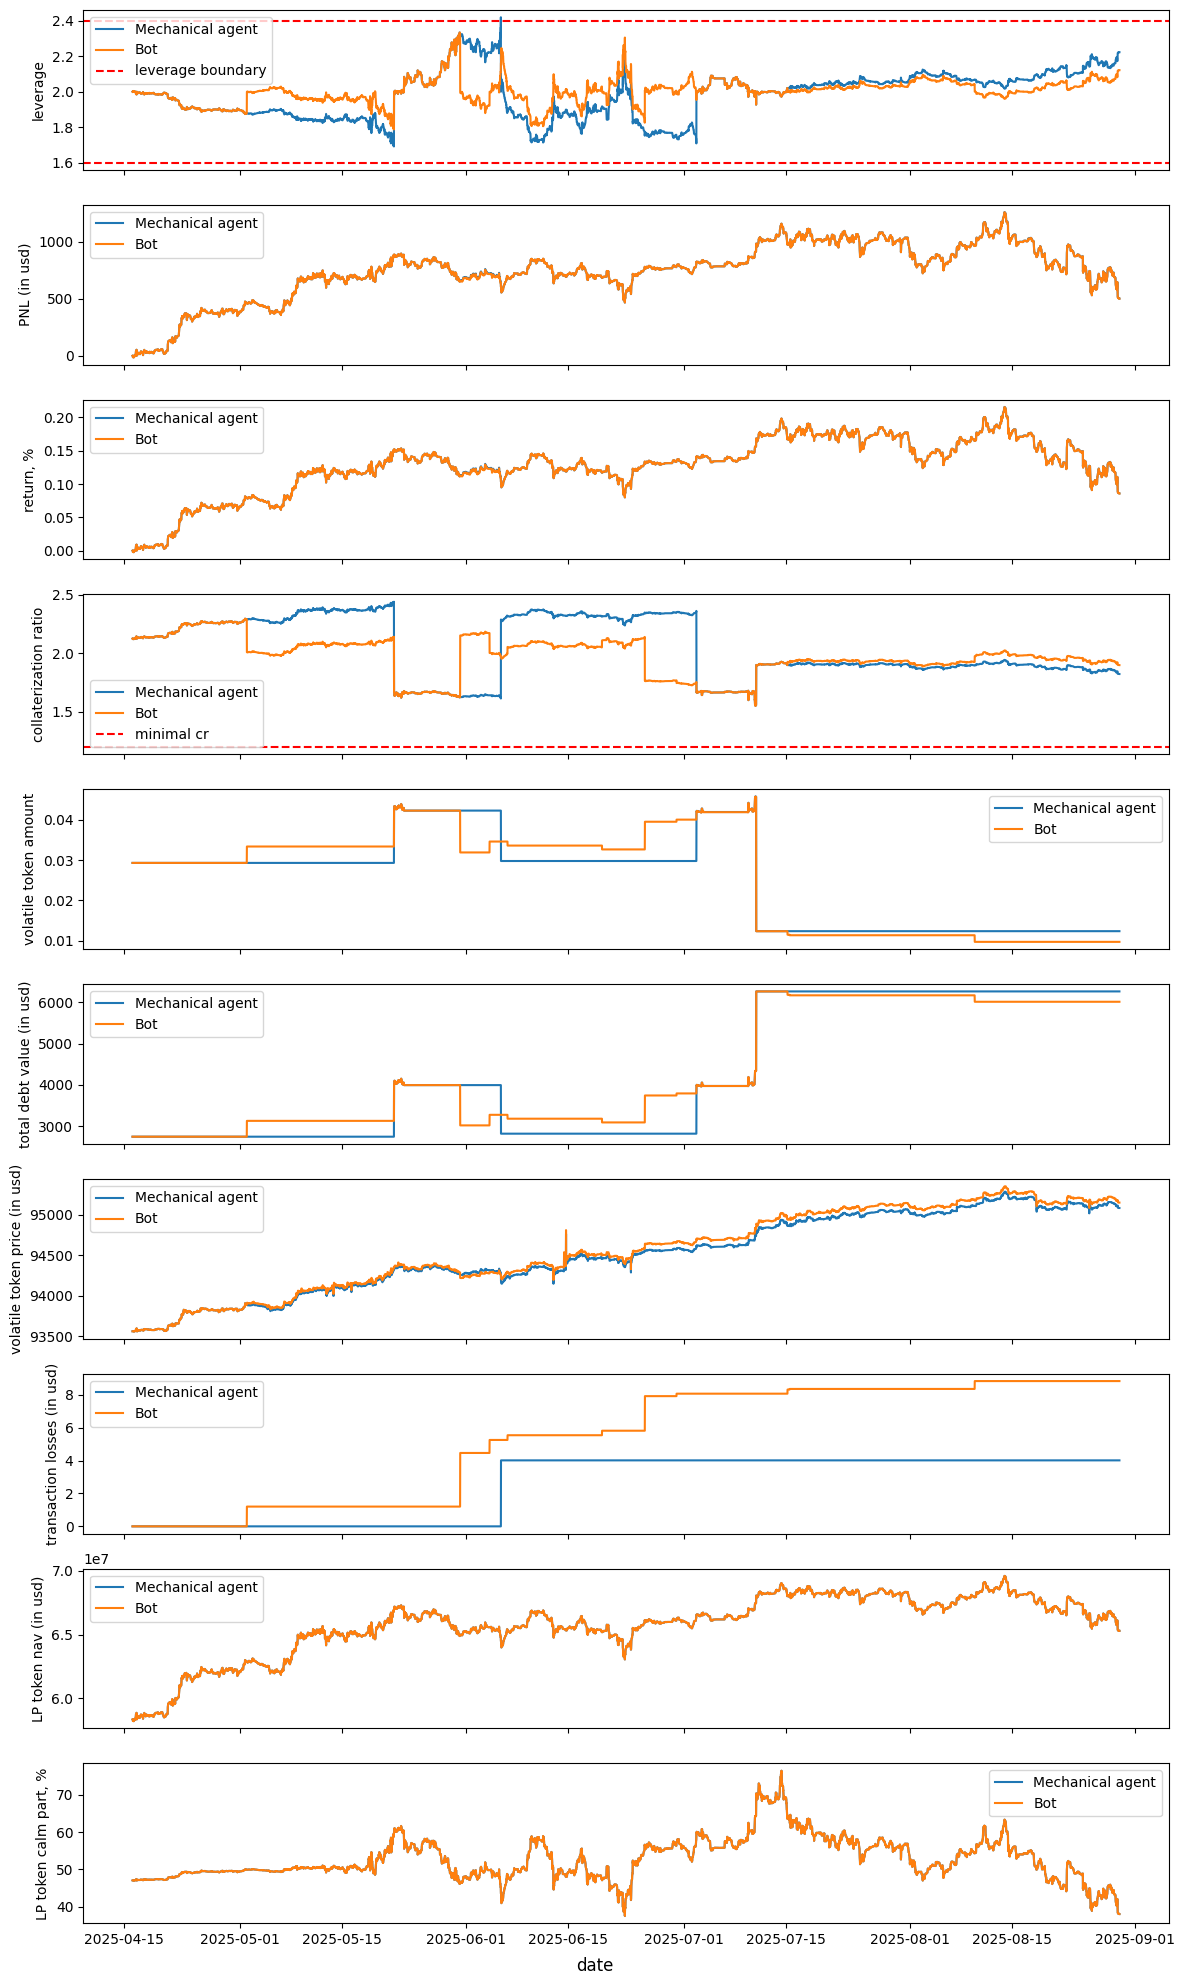

In [13]:
plot_economic_metrics([mech_agent_history, bot_history], ['Mechanical agent', 'Bot'], 2.4, 1.6)